In [19]:
import pandas as pd
from sklearn.impute import SimpleImputer
from Univariate import Univariate
function = Univariate
dataset = pd.read_csv("Placement.csv")

In [2]:


quan,qual= function.quanQual(dataset)

numericalValues = function.numaric_nan_values(dataset, quan)


# Convert NumPy arrays to DataFrames before concatenating
numerical_df = pd.DataFrame(numericalValues, columns=quan)

# # Now concatenate the DataFrames
dataset = pd.concat([numerical_df], axis=1)

dataset

# Replace the NaN values with correct value. And justify why you have chosen the same


,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
0,1.0,67.00,91.00,58.00,55.0,58.80,270000.000000
1,2.0,79.33,78.33,77.48,86.5,66.28,200000.000000
2,3.0,65.00,68.00,64.00,75.0,57.80,250000.000000
3,4.0,56.00,52.00,52.00,66.0,59.43,288655.405405
4,5.0,85.80,73.60,73.30,96.8,55.50,425000.000000
...,...,...,...,...,...,...,...
210,211.0,80.60,82.00,77.60,91.0,74.49,400000.000000
211,212.0,58.00,60.00,72.00,74.0,53.62,275000.000000
212,213.0,67.00,67.00,73.00,59.0,69.72,295000.000000
213,214.0,74.00,66.00,58.00,70.0,60.23,204000.000000


In [3]:
# How many of them are not placed?

dataset = pd.read_csv("Placement.csv")

dataset["status"].value_counts()



status
Placed        148
Not Placed     67
Name: count, dtype: int64

In [38]:
# Find the reason for non placement from the dataset?

dataset = pd.read_csv("Placement.csv")
grouped = dataset.groupby("status").mean(numeric_only=True)

print(grouped)

# Not Placed students generally have lower academic scores

                 sl_no      ssc_p      hsc_p   degree_p    etest_p      mba_p  \
status                                                                          
Not Placed  110.477612  57.544030  58.395522  61.134179  69.587910  61.612836   
Placed      106.878378  71.721486  69.926554  68.740541  73.238041  62.579392   

                   salary  
status                     
Not Placed            NaN  
Placed      288655.405405  


In [5]:
# What kind of relation between salary and mba_p

quan,qual= function.quanQual(dataset)

numericalValues = function.numaric_nan_values(dataset, quan)


# Convert NumPy arrays to DataFrames before concatenating
numerical_df = pd.DataFrame(numericalValues, columns=quan)

# # Now concatenate the DataFrames
dataset = pd.concat([numerical_df], axis=1)

correlation = dataset["mba_p"].corr(dataset["salary"])
print("Correlation:", correlation)

# Correlation Value      Meaning

# 0 to 0.2               Very weak

# 0.2 to 0.4             Weak

# 0.4 to 0.6             Moderate

# 0.6 to 0.8             Strong

# 0.8 to 1               Very strong


# Correlation percentage value is 14% meaning is very week

Correlation: 0.14632449006038745


In [6]:
# Which specialization is getting minimum salary?
dataset = pd.read_csv("Placement.csv")
dataset.groupby("specialisation")["salary"].mean().idxmin()

# Mkt&HR specialization is getting 

'Mkt&HR'

In [7]:
count = (dataset["salary"] > 500000).sum()
print("Number of employee getting above 500000 salary:", count)

Number of employee getting above 500000 salary: 3


In [4]:
# Test the Analysis of Variance between etest_p and mba_p at signifance
# level 5%.(Make decision using Hypothesis Testing)
from scipy.stats import ttest_ind
dataset = pd.read_csv("Placement.csv")

ttest_ind(dataset["etest_p"], dataset["mba_p"])

#Test the Analysis of Variance between etest_p and mba_p at no signifance

# Accecpt null hypothesi adn reject alternative hypothiss

TtestResult(statistic=np.float64(9.932012413063472), pvalue=np.float64(4.672547689134019e-21), df=np.float64(428.0))

In [2]:
# Test the similarity between the degree_t(Sci&Tech) and specialisation(Mkt&HR) with respect to salary at significance level of 5%.(Make
# decision using Hypothesis Testing)

value = function.t_test_cal(dataset, "degree_t", "specialisation", "Sci&Tech", "Mkt&HR", "salary", "salary")
value

# Reject null hypothesis p_value is lesser then 5%


{'column': 'degree_t',
 'column2': 'specialisation',
 'filter': 'Sci&Tech',
 'filter2': 'Mkt&HR',
 'target_col': 'salary',
 'target_col2': 'salary',
 't_stat': np.float64(2.734391160944239),
 'p_value': np.float64(0.007496896218767113)}

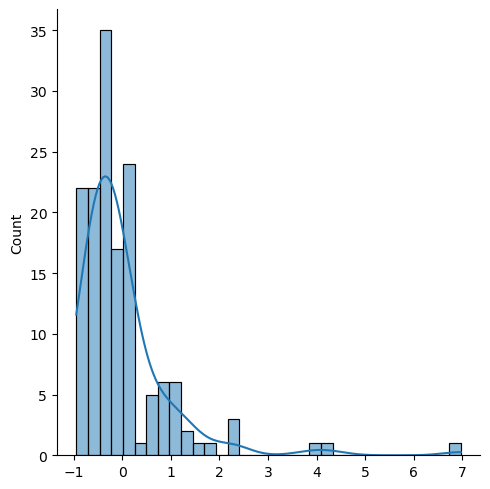

In [3]:
# Convert the normal distribution to standard normal distribution for
# salary column


function.std_graph(dataset["salary"])
    

The area between range(700000:900000):5.377578376230696e-06


np.float64(5.377578376230696e-06)

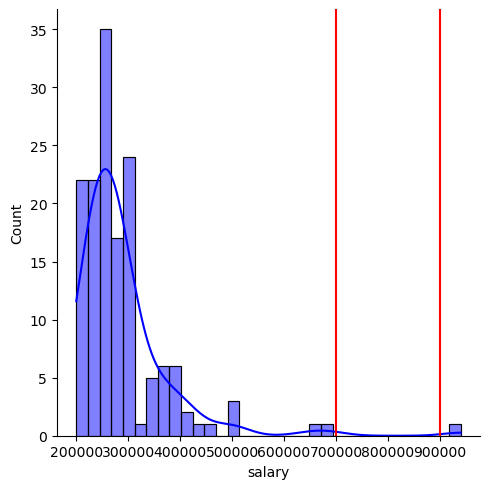

In [6]:
# What is the probability Density Function of the salary range from
# 700000 to 900000?
import seaborn as sns

dataset = pd.read_csv("Placement.csv")

dataset1 = dataset.dropna()

def get_pdf_probility (dataset, start, end):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    sns.displot(dataset, kde=True, color="blue")
    pyplot.axvline(start, color="red")
    pyplot.axvline(end, color="red")
    sample_mean=dataset.mean()
    sample_std=dataset.std()
    dist= norm(sample_mean, sample_std)
    values = [value for value in range(start, end)]
    probilities= [dist.pdf(value) for value in values]
    prob= sum(probilities)
    print("The area between range({}:{}):{}".format(start, end, sum(probilities)))
    return prob

get_pdf_probility(dataset1["salary"], 700000, 900000)


In [11]:
# Test the similarity between the degree_t(Sci&Tech)with respect to
# etest_p and mba_p at significance level of 5%.(Make decision using Hypothesis Testing)

from scipy.stats import ttest_ind
dataset = pd.read_csv("Placement.csv")

mainfilter = dataset[dataset["degree_t"] == "Sci&Tech"]

group=mainfilter["etest_p"].dropna()
group2=mainfilter["mba_p"].dropna()

t_stat, p_value = ttest_ind(group, group2)

print("T-statistic:", t_stat)

print("P-value:", p_value)

    
#P-value is more than 5% Accecpt null hypothesi and reject alternative hypothiss


T-statistic: 4.532000225151251
P-value: 1.4289217003775638e-05


In [34]:
# Which parameter is highly correlated with salary
dataset = pd.read_csv("Placement.csv")

dataset1= dataset.dropna()


correlation = dataset.corr(numeric_only=True)["salary"].drop("salary").idxmax()
print(correlation)


etest_p


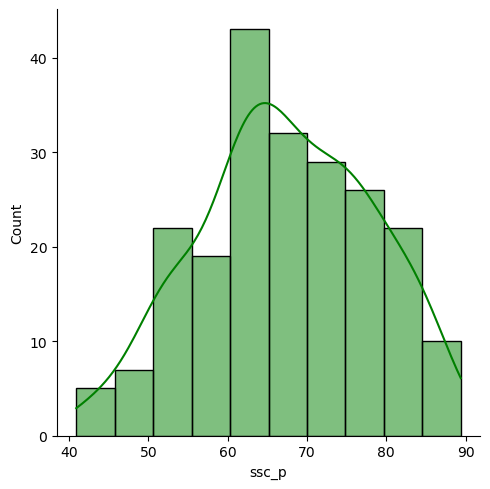

In [37]:
# plot any useful graph and explain it
import seaborn as sns

dataset = pd.read_csv("Placement.csv")

sns.displot(dataset["ssc_p"], kde=True, color="green")
